In [12]:
# Import libraries and set directories
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import softmax
from sklearn.metrics import precision_recall_fscore_support, accuracy_score


output_dir = "/home/paul/Msci/plots/inference/multiclass/"

run = "run 1"

In [9]:
if run == "run 1":

    data_dir = "/home/paul/Msci/dm_sets_multiclass/run1/"
    file_mapping = [
        ("run1_NuMI_nu_overlay_larcv_cropped_scores_multiclass.csv", "In cryo"),
        ("run1_NuMI_dirt_larcv_cropped_scores_multiclass.csv", "Out of cryo"),
        ("run1_offbeam_larcv_cropped_full_set_scores_multiclass.csv", "Beam-off"),
        ("run1_dt_ratio_0.6_ma_0.05_pi0_larcv_cropped_scores_multiclass.csv", "Dark Trident"),
    ]
else:
    
    data_dir = "/home/paul/Msci/dm_sets_multiclass/run3/"
    file_mapping = [
        ("run3_nu_overlay_larcv_cropped_scores_multiclass.csv", "In cryo"),
        ("run3_dirt_larcv_cropped_scores_multiclass.csv", "Out of cryo"),
        ("run3_offbeam_larcv_cropped_scores_multiclass.csv", "Beam-off"),
        ("run3_dt_ratio_0.6_ma_0.05_pi0_larcv_cropped_scores_multiclass.csv", "Dark Trident"),
    ]


class_names = ["NCπ0", "Cosmics", "DM Signal", "Uncertain"]

dfs = []
for filename, label in file_mapping:
    path = os.path.join(data_dir, filename)
    df = pd.read_csv(path)
    df["true_label"] = label
    dfs.append(df)
    print(f"Loaded {label}: {len(df)} events")

full_df = pd.concat(dfs, ignore_index=True)

Loaded In cryo: 13770 events
Loaded Out of cryo: 3331 events
Loaded Beam-off: 3889 events
Loaded Dark Trident: 4219 events


In [10]:
# Define threshold
threshold = 0.4

true_labels = ["In cryo", "Out of cryo", "Beam-off", "Dark Trident"]

cm = np.zeros((4, 4), dtype=int)

for i, true_label in enumerate(true_labels):
    subset = full_df[full_df['true_label'] == true_label]

    logits = subset[['p0', 'p1', 'p2']].values
    probs = softmax(logits, axis=1)

    max_probs = probs.max(axis=1)
    pred_classes = probs.argmax(axis=1)   # 0,1,2 for NCπ0/Cosmics/Signal

    pred_classes_with_na = np.where(max_probs >= threshold, pred_classes, 3)

    for j in range(4):
        cm[i, j] = (pred_classes_with_na == j).sum()

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[9596 1617 1832  725]
 [1973  897  194  267]
 [2451 1028  136  274]
 [ 218   70 3868   63]]


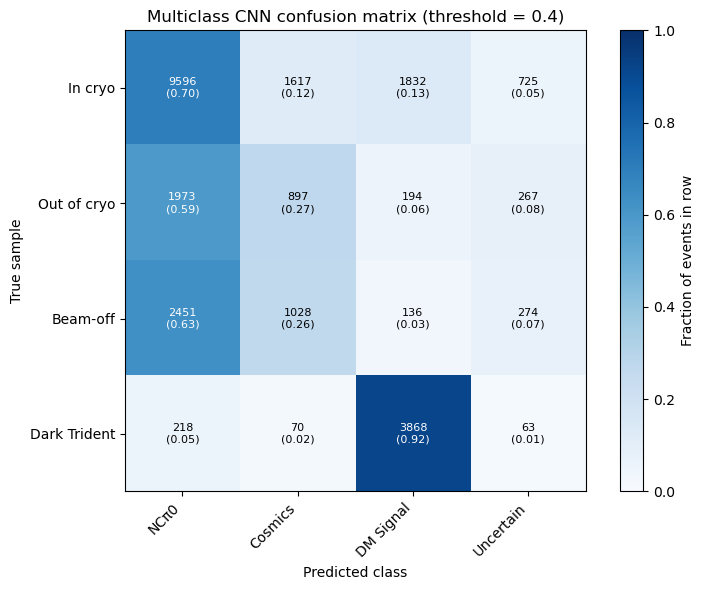

Saved confusion matrix to /home/paul/Msci/plots/inference/multiclass/confusion_matrix_multiclass_thr0.40.png


In [11]:
# Normalise rows to fractions
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm_norm, cmap="Blues", vmin=0.0, vmax=1.0)

# Tick labels
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(true_labels)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(true_labels)

# Annotate each cell with count and fraction
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        frac = cm_norm[i, j]
        ax.text(
            j, i,
            f"{count}\n({frac:.2f})",
            ha="center", va="center",
            fontsize=8,
            color="black" if frac < 0.5 else "white",
        )

ax.set_xlabel("Predicted class")
ax.set_ylabel("True sample")
ax.set_title(f"Multiclass CNN confusion matrix (threshold = {threshold})")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Fraction of events in row")

plt.tight_layout()

out_path = os.path.join(output_dir, f"confusion_matrix_multiclass_thr{threshold:.2f}.png")
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved confusion matrix to {out_path}")

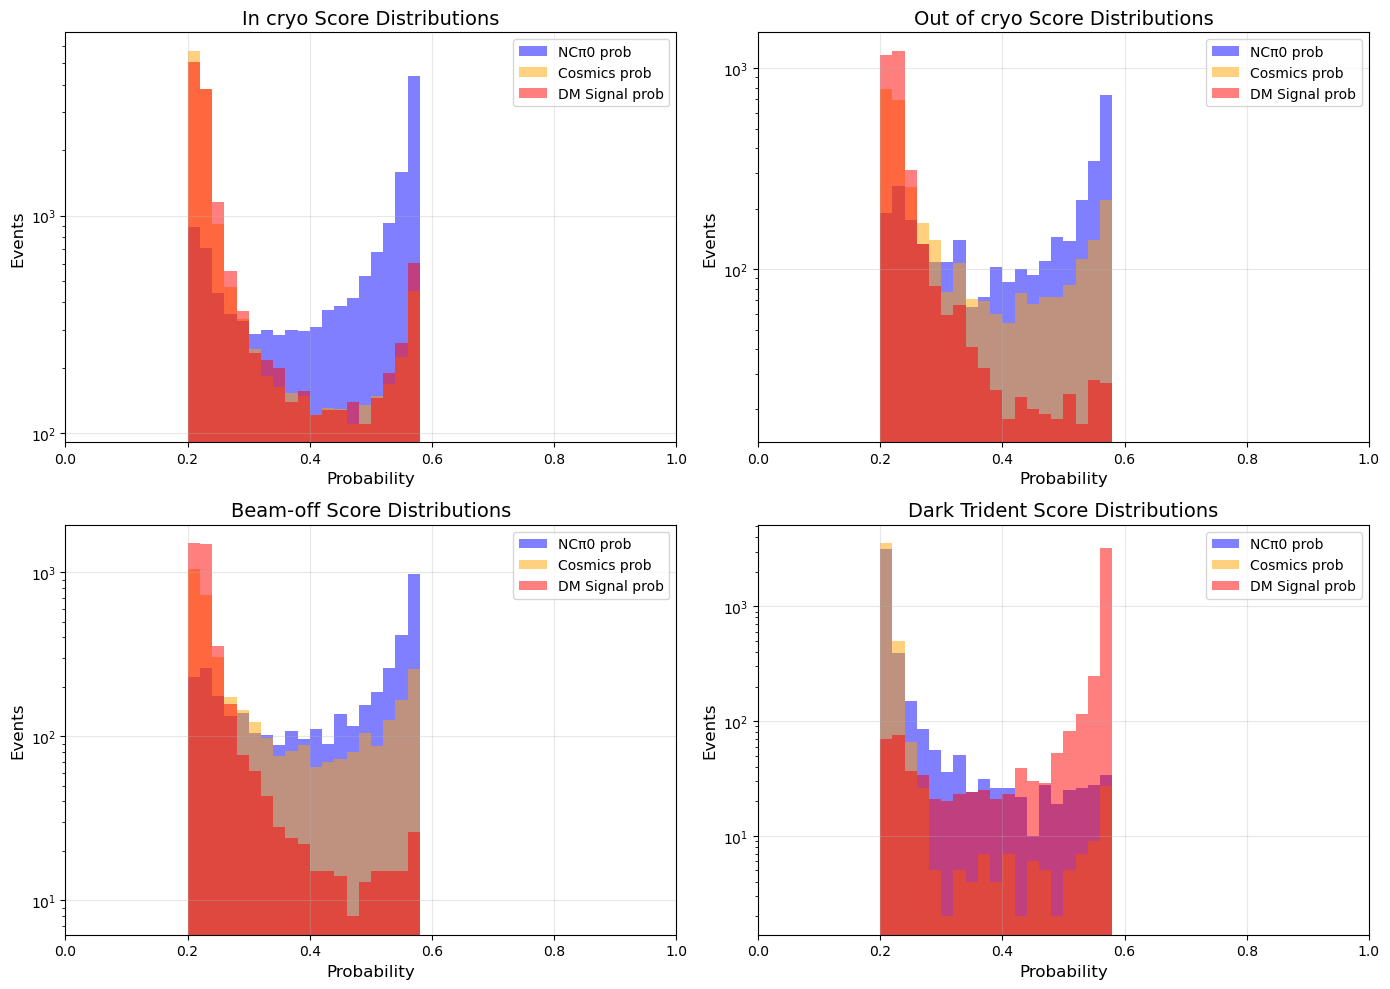

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (filename, label) in enumerate(file_mapping):
    ax = axes[idx]
    df_class = dfs[idx]

    logits = df_class[['p0', 'p1', 'p2']].values
    probs = softmax(logits, axis=1)

    ax.hist(probs[:, 0], bins=50, alpha=0.5, label='NCπ0 prob', color='blue', range=(0,1))
    ax.hist(probs[:, 1], bins=50, alpha=0.5, label='Cosmics prob', color='orange', range=(0,1))
    ax.hist(probs[:, 2], bins=50, alpha=0.5, label='DM Signal prob', color='red', range=(0,1))
    
    ax.set_xlabel('Probability', fontsize=12)
    ax.set_ylabel('Events', fontsize=12)
    ax.set_title(f'{label} Score Distributions', fontsize=14)
    ax.legend(fontsize=10)
    ax.set_yscale('log')
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "run3_score_distributions_by_class.png"), dpi=300)
plt.savefig(os.path.join(output_dir, "run3_score_distributions_by_class.pdf"))
plt.show()